# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
* A linear model assumes linearity for making predictions. In regression models, either a single or multiple variables impact the dependent variable. This is expressed in a linear equation with a constant and coefficients.
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
* For dummy/one-hot-encoded variables, the coefficent indicates the effect that specific variable has on the dependent variable, controlling for all other variables. This is not enough to draw a causal conclusion, but instead indicates the average impact on y-hat for that particular variable compared to the variable that was dropped. Like the intercept, which indicates the predicted value when every variable is equal to 0 (and by itself does not hold much meaning), the coefficients of dummy variables are relative to something else that gives it meaning.
3. Can linear regression be used for classification? Explain why, or why not.
* Linear regression is specialized for making numeric predictions based on an assortment of variables. It allows for global smoothing, or aggregating variables into predictions. Linear regression would not be ideal for classification.
4. What are signs that your linear model is over-fitting?
* The model may be over-fitted if there is high variance but low bias and high expected loss. Also, if the model is too complex and complicated it is likely over-fitted.
5. Clearly explain multi-colinearity using the two-stage least squares technique.
* When two variables are highly correlated with each other and y, they may have a similar, overlapping effect on the target variable. This is not ideal because we want concise predictions. The two-stage least squares technique is a way to figure out if this is happening between variables by running a regression between the selected explanatory variable and all other variables and y. Using the residuals from the regressions in the previous step, run a single regression between the residuals.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
* Through polynomial expansion and Scikit's polynomial expander. Depending on the context of the data, we can also use one-hot encoding or Fourier Series to make analysis easier.
7. What is the interpretation of the slope coefficient in a linear regression?
* The slope coefficient implies that the target variable increases, on average, by the value of the explanatory variable's coefficient, controlling for all other variables, as its value increases by 1.
8. Compare the train/test split and $k$-fold cross validation.
* k-fold cross validation is basically a series of train-test splits. Both methods include splitting the data for testing and training the model, but since the results from a single train-test split can be variable, the k-fold cross validation method allows us to have a more detailed understanding of the model's performance.
9. How is the $k$ in $k$-fold cross validation typically selected?
* The number of folds is influenced by the number of times you want to split the data, considering its size, how the model performs at a given k (add less or more to optimize accuracy), and how long you want the process to take (it takes time to do a lot of splits).

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [11]:
# packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import make_scorer

In [5]:
# load in data
! git clone https://github.com/AngelikaBaloy/undergrad_ml_assignments/
Q1_clean = pd.read_csv('./undergrad_ml_assignments/data/Q1_clean.csv')
Q1_clean.head()
Q1_clean.columns

Cloning into 'undergrad_ml_assignments'...
remote: Enumerating objects: 174, done.
remote: Counting objects: 100% (78/78), done.
remote: Compressing objects: 100% (59/59), done.
remote: Total 174 (delta 66), reused 19 (delta 19), pack-reused 96 (from 1)
Receiving objects: 100% (174/174), 17.22 MiB | 24.74 MiB/s, done.
Resolving deltas: 100% (78/78), done.


Index(['Price', 'Review Scores Rating', 'Neighbourhood ', 'Property Type',
       'Room Type'],
      dtype='object')

Neighbourhood 
Bronx             75.276498
Brooklyn         127.747378
Manhattan        183.664286
Queens            96.857233
Staten Island    146.166667
Name: Price, dtype: float64


<Axes: xlabel='Price', ylabel='Density'>

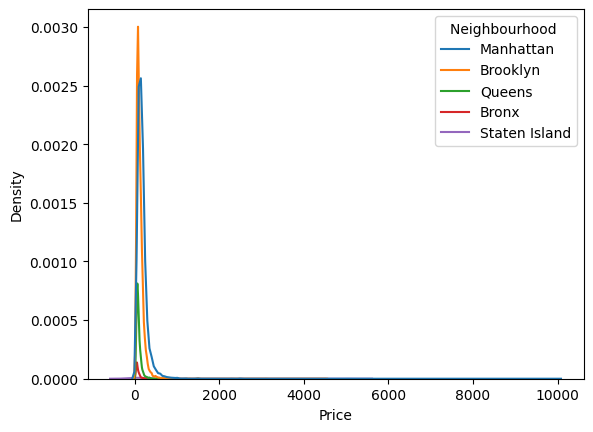

In [ ]:
# Q1: compute avg prices and scores by neighborhood
print(Q1_clean['Price'].groupby(Q1_clean['Neighbourhood ']).mean())
# Manhattan is the most costly on average
Q1_clean['Review Scores Rating'].groupby(Q1_clean['Neighbourhood ']).mean()

# kdeplot of price by neighborhood
sns.kdeplot(data=Q1_clean, x='Price', hue='Neighbourhood ')

<Axes: xlabel='log_price', ylabel='Density'>

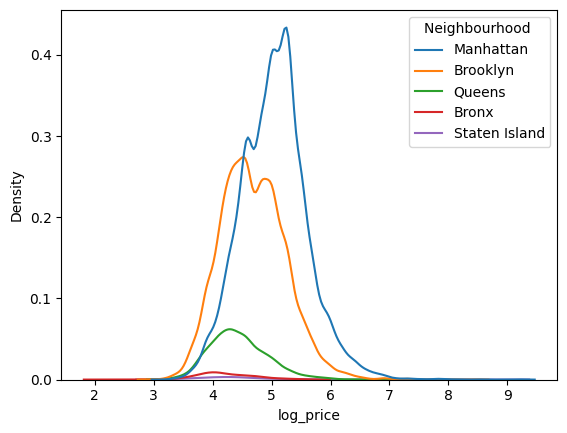

In [ ]:
# kdeplot for log price by neighborhood
Q1_clean['log_price'] = np.log(Q1_clean['Price'])
sns.kdeplot(data=Q1_clean, x='log_price', hue='Neighbourhood ')

In [ ]:
# Q2: Regress price on neighborhood
ohc_nbh = pd.get_dummies(Q1_clean['Neighbourhood '], dtype='int', drop_first=True)
x = ohc_nbh # dropped Bronx
y = Q1_clean['Price']

model= LinearRegression()
model= model.fit(x,y)

print(f'Model intercept: {model.intercept_}')
pd.DataFrame({'variable':model.feature_names_in_, 'coefficient':model.coef_ })

# Conditional group means and the estimated coefficients:
# The coefficients are equivalent to their group means minus Bronx's group mean

Model intercept: 75.27649769585331


,variable,coefficient
0,Brooklyn,52.470881
1,Manhattan,108.387789
2,Queens,21.580735
3,Staten Island,70.890169


In [ ]:
# Q3. Regress price on rating and a constant
constant = pd.Series(np.ones(Q1_clean.shape[0]), name='Constant')
x = pd.concat([constant, Q1_clean['Review Scores Rating']], axis=1)

y = Q1_clean['Price']

model= LinearRegression()
model= model.fit(x,y)

print(f'Model intercept: {model.intercept_}')
pd.DataFrame({'variable':model.feature_names_in_, 'coefficient':model.coef_ })

# Interpret slope coefficient: For every 1pt increase in rating, the price, on
# average, increases by 1.021

Model intercept: 60.87839065712359


,variable,coefficient
0,Constant,0.000000
1,Review Scores Rating,1.020827


In [ ]:
# Q4: Regress price on review scores rating and neighborhood
x = pd.concat([Q1_clean['Review Scores Rating'], ohc_nbh], axis=1)

y = Q1_clean['Price']

model= LinearRegression()
model= model.fit(x,y)

print(f'Model intercept: {model.intercept_}')
pd.DataFrame({'variable':model.feature_names_in_, 'coefficient':model.coef_ })

# Compared to the last model, the RSR coefficent increased slightly.
# The neighborhood averages remained similar, with minute increases and decreases.


Model intercept: -23.812561011673324


,variable,coefficient
0,Review Scores Rating,1.081116
1,Brooklyn,51.704240
2,Manhattan,108.228737
3,Queens,21.694600
4,Staten Island,71.766552


In [ ]:
# Q5: Regress price on constant, and a separate slope coefficent for each neighborhood for RSR


Model intercept: 60.87839065712359


array([0.       , 1.0208266])

In [ ]:
# cross validating models
# from Q3:


constant = pd.Series(np.ones(Q1_clean.shape[0]), name='Constant')
x = pd.concat([constant, Q1_clean['Review Scores Rating']], axis=1)

y = Q1_clean['Price']

model= LinearRegression()
model= model.fit(x,y)

kfold = KFold(n_splits=10, shuffle=True, random_state=100) # 10 splits

mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)

scores = cross_val_score(
    model,x,y,
    cv=kfold,
    scoring=mse_scorer # Use the created scorer
)

print("Fold scores:", -scores)
print("Mean score:", -np.mean(scores))
print("Median score:", -np.median(scores))
print("Std dev:", np.std(scores))

Fold scores: [14525.62587895 18785.03156182 23315.65390815 21485.08112418
 17377.37412282 16911.65764952 66505.14612181 12010.92688963
 13867.65309739 16010.97323341]
Mean score: 22079.512358769138
Median score: 17144.515886169527
Std dev: 15158.786803772266


In [ ]:
# cross validating Q4 model
x = pd.concat([Q1_clean['Review Scores Rating'], ohc_nbh], axis=1)

y = Q1_clean['Price']

model= LinearRegression()
model= model.fit(x,y)

kfold = KFold(n_splits=10, shuffle=True, random_state=100) # 10 splits

mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)

scores = cross_val_score(
    model,x,y,
    cv=kfold,
    scoring=mse_scorer
)

print("Fold scores:", -scores)
print("Mean score:", -np.mean(scores))
print("Median score:", -np.median(scores))
print("Std dev:", np.std(scores))

Fold scores: [13328.8844614  17923.91602978 22359.73425128 20638.78463036
 16213.77913811 15968.25148456 65543.4120206  11112.83183507
 12726.79546542 14924.58455652]
Mean score: 21074.09738730938
Median score: 16091.015311334519
Std dev: 15184.490093017015


In [ ]:
# cross validating Q5 model

# input code here once u figure it out

model= LinearRegression()
model= model.fit(x,y)

kfold = KFold(n_splits=10, shuffle=True, random_state=100) # 10 splits

mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)

scores = cross_val_score(
    model,x,y,
    cv=kfold,
    scoring=mse_scorer
)

print("Fold scores:", -scores)
print("Mean score:", -np.mean(scores))
print("Median score:", -np.median(scores))
print("Std dev:", np.std(scores))

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


In [6]:
# load in data
cars = pd.read_csv('./undergrad_ml_assignments/data/cars_hw.csv')
cars.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64


<Axes: xlabel='Price', ylabel='Density'>

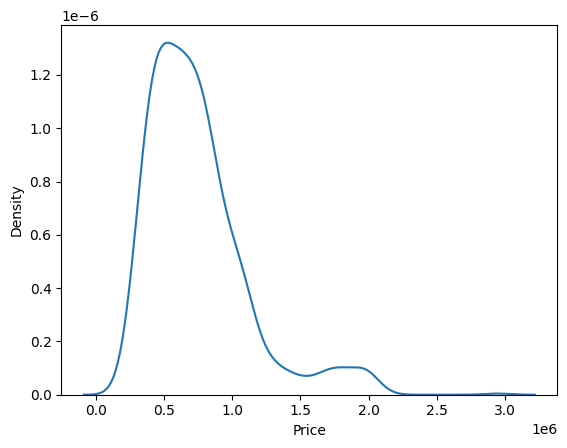

In [ ]:
# Q1: summarize price and create kdeplot
print(cars['Price'].describe())
sns.kdeplot(data=cars, x='Price')

           count          mean            std       min       25%        50%  \
Body_Type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        1491250.0  2100000.0  


<Axes: xlabel='Price', ylabel='Density'>

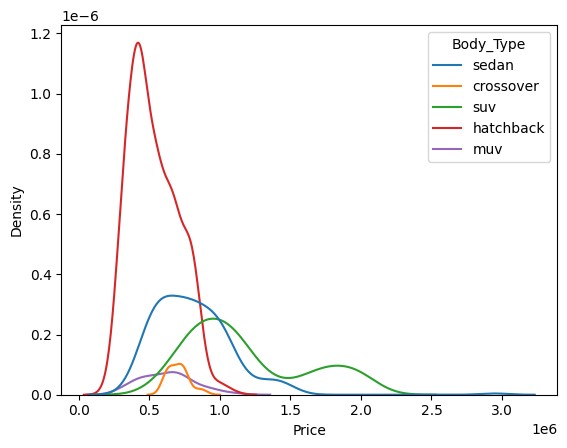

In [ ]:
# prices by body type
print(cars['Price'].groupby(cars['Body_Type']).describe())
sns.kdeplot(data=cars, x='Price', hue='Body_Type')

# Going by the group means, suvs and sedans are generally the most expensive.
# Suvs also have the most variance, while sedan prices are highly variable as well.
# There are some really expensive sedans here, but most of them aren't.

In [ ]:
# Q2: Regress price on seating capacity

x = cars[['Seating_Capacity']]
y = cars['Price']

model= LinearRegression()
model= model.fit(x,y)

print(f'Model intercept: {model.intercept_}')
pd.DataFrame({'variable':model.feature_names_in_, 'coefficient':model.coef_ })

# the slope coefficient is 59267.998
# For every additional seat, the price of a car, on average, increases by 59268 rupees

Model intercept: 439032.0141018266


,variable,coefficient
0,Seating_Capacity,59267.998037


Model intercept: 188000.00000000314
   variable   coefficient
0         5  5.464839e+05
1         6  1.456000e+06
2         7  7.359487e+05
3         8  2.718000e+05


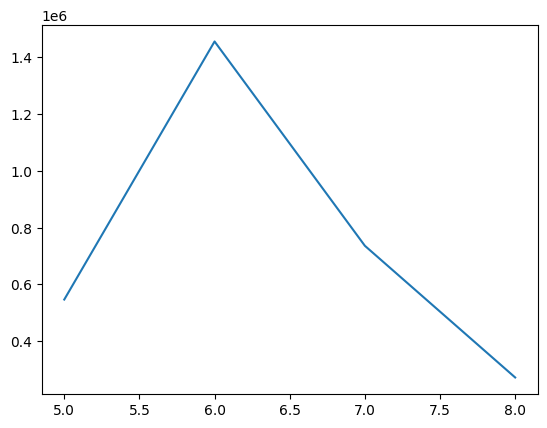

In [ ]:
# Q2: Regress price on seating capacity (as one hot encoded)

ohe_seat = pd.get_dummies(cars['Seating_Capacity'], dtype='int', drop_first=True)
x = ohe_seat # dropped 4 seats
y = cars['Price']

model= LinearRegression()
model= model.fit(x,y)

print(f'Model intercept: {model.intercept_}')
print(pd.DataFrame({'variable': x.columns, 'coefficient':model.coef_ }))


import matplotlib.pyplot as plt
plt.plot(x.columns, model.coef_)

# The prices don't seem to be linear in relation to the number of seats.
# Price doesn't go up with 8-seaters.

In [8]:
# Q3: create new variable that corresponds to vehicle age using make_year
cars['Age'] = 2026 - cars['Make_Year']
cars['Age'].describe() # mean age is about 9 years, max is only 15

x = cars[['Age']]

y = cars['Price']

model= LinearRegression()
model= model.fit(x,y)

kfold = KFold(n_splits=10, shuffle=True, random_state=100) # 10 folds

mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)

scores = cross_val_score(
    model,x,y,
    cv=kfold,
    scoring=mse_scorer
)

print("Fold scores:", -scores)
print("Mean score:", -np.mean(scores))
print("Median score:", -np.median(scores))
print("Std dev:", np.std(scores))
# return to this to see if it is correct

Fold scores: [9.05629877e+10 1.04590149e+11 8.35150173e+10 9.42889896e+10
 9.57961145e+10 8.23002081e+10 1.29209046e+11 1.10209665e+11
 7.53798399e+10 1.10087901e+11]
Mean score: 97593991873.84819
Median score: 95042552057.2941
Std dev: 15339123765.102116


<Axes: xlabel='Age', ylabel='Price'>

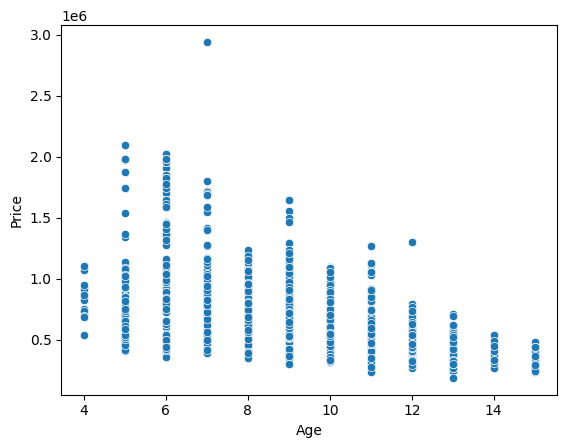

In [13]:
# 4. plot price against age
sns.scatterplot(x= cars['Age'], y= cars['Price'], data=cars)

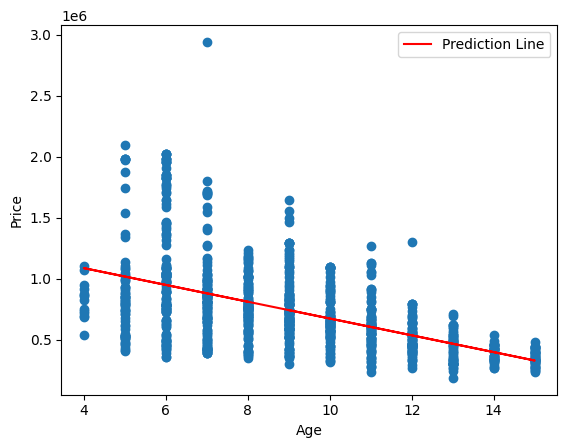

In [19]:
# 4. plot price against age and model-predicted price and age

x = cars[['Age']]

y = cars['Price']

model= LinearRegression()
model= model.fit(x,y)
y_hat= model.predict(x)

plt.scatter(x= cars['Age'], y= cars['Price'])
plt.plot(x, y_hat, label="Prediction Line", color='red')
plt.xlabel("Age")
plt.ylabel("Price")
plt.legend(loc='upper right')

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [20]:
# load in data
heart = pd.read_csv('./undergrad_ml_assignments/data/heart_hw.csv')
heart.head()

,Unnamed: 0,age,transplant,y
0,1,53,control,0
1,2,43,control,0
2,3,52,control,0
3,4,52,control,0
4,5,54,control,0


In [ ]:
# 1. (a) compute proportion of people who survive in the control group

heart['y'].groupby(heart['transplant']).sum() / heart['y'].groupby(heart['transplant']).count()
# 1 is survival / total
# Roughly 11.8% of people in the control group survive

# (b) proportion of people who survive in the treatment group

# Roughly 34.8% of people in the treatment group survive. Better odds.

,y
transplant,
control,0.117647
treatment,0.347826


In [26]:
# 1. compute (b) - (a) as the average treatment effect (ATE)
ATE = 0.347826 - 0.117647
print(ATE) # ATE = 0.23

0.23017900000000002


In [41]:
# 2. Regress y on transplant

y = heart['y']
x = pd.get_dummies(heart['transplant'], dtype='int', drop_first=True) # dropping control

model= LinearRegression()
model= model.fit(x,y)

print(f'Model intercept: {model.intercept_}')
print(pd.DataFrame({'variable': model.feature_names_in_, 'coefficient':model.coef_ }))

# The model intercept is equivalent to the proportion of people who survived in the control group.
# The transplant coefficient is equivalent to the average treatment effect.


Model intercept: 0.1176470588235293
    variable  coefficient
0  treatment     0.230179


In [40]:
# 3. Regress y on transplant and age

y = heart['y']

ohe_treat = pd.get_dummies(heart['transplant'], dtype='int', drop_first=True) # dropping control
x = pd.concat([ohe_treat, heart['age']], axis=1)

model= LinearRegression()
model= model.fit(x,y)

print(f'Model intercept: {model.intercept_}')
print(pd.DataFrame({'variable': model.feature_names_in_, 'coefficient':model.coef_ }))

# After controlling for age, the transplant coefficient increases slightly, indicating that transplants have more positive impact on the outcome.
# The coefficient for age is negative, suggesting that as age increases, it is associated with worse outcomes.
# The intercept indicates that, when all variables are 0, the outcome leans towards death. This has limited utility.

Model intercept: 0.7019569721740947
    variable  coefficient
0  treatment     0.264702
1        age    -0.013607


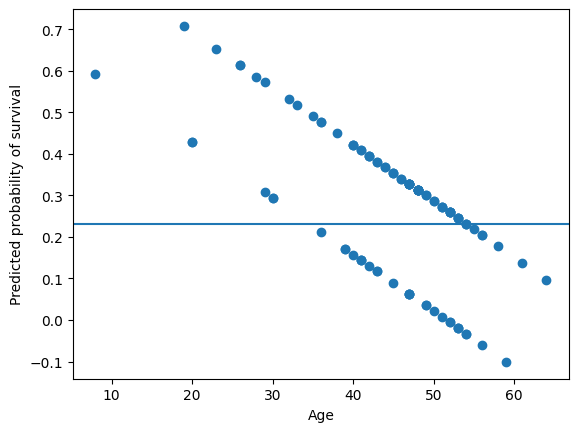

In [29]:
# Plot the predicted probability of survival by age
# For what ages is the ATE over- or under-estimating

y = heart['y']

ohe_treat = pd.get_dummies(heart['transplant'], dtype='int', drop_first=True) # dropping control
x = pd.concat([ohe_treat, heart['age']], axis=1)

model= LinearRegression()
model= model.fit(x,y)
y_hat= model.predict(x)

plt.scatter(x=heart['age'], y=y_hat)
plt.xlabel("Age")
plt.ylabel("Predicted probability of survival")
plt.axhline(y=ATE)

# For this model, the ATE is underestimating survival for the younger portion of the data set.
# Those under 35 have higher probability of survival. While those over 35, the ATE is overestimating
# their probability of survival. This horizontal line is not doing a very good job overall.

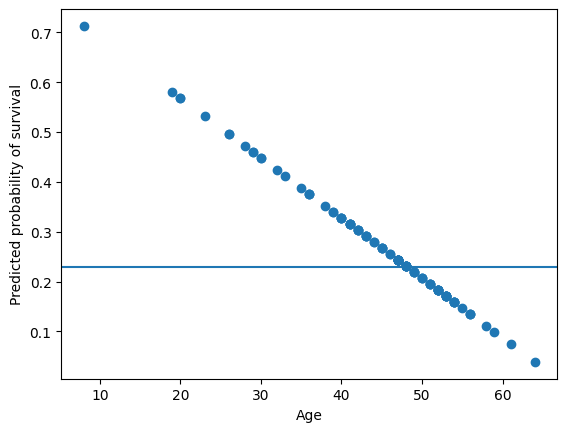

In [31]:
# just age

y = heart['y']

x = heart[['age']]

model= LinearRegression()
model= model.fit(x,y)
y_hat= model.predict(x)

plt.scatter(x=heart['age'], y=y_hat)
plt.xlabel("Age")
plt.ylabel("Predicted probability of survival")
plt.axhline(y=ATE)
# When the model is just using age as a predictor, the ATE is over- and under- estimating in a
# similar pattern. The probability of survival is underestimated up to age 47 or so.
# The probability of survival is overestimated after that.

Model intercept: 0.35486517529945855
          variable  coefficient
0        treatment     0.907751
1              age    -0.005524
2  treatment_x_age    -0.014591


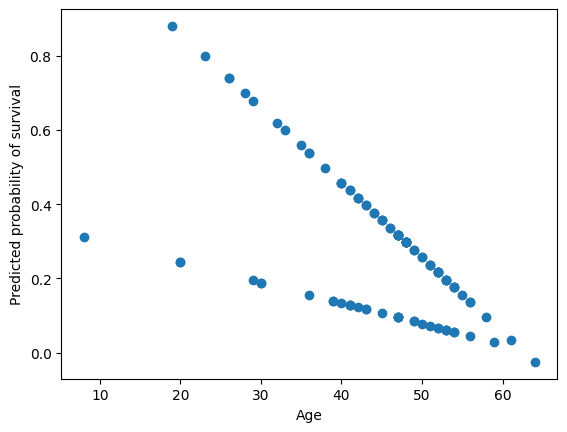

In [39]:
# including interaction transplant*age

y = heart['y']

ohe_treat = pd.get_dummies(heart['transplant'], dtype='int', drop_first=True)

tr_age = ohe_treat['treatment'] * heart['age']
tr_age.name = 'treatment_x_age'

x= pd.concat([ohe_treat, heart['age'], tr_age], axis=1)

model= LinearRegression()
model= model.fit(x,y)

y_hat= model.predict(x)

print(f'Model intercept: {model.intercept_}')
print(pd.DataFrame({'variable': model.feature_names_in_, 'coefficient':model.coef_ }))

plt.scatter(x=heart['age'], y=y_hat)
plt.xlabel("Age")
plt.ylabel("Predicted probability of survival")
plt.title= "Predicted probability of survival including interaction effects (transplant&age)"


# [commentary]

In [ ]:
# 5. 10-fold cross validation

In [ ]:
# 6. Imagine this model is used to prioritize transplant access. What are your concerns about
# model construction and deployment?


